In [167]:
import numpy as np
import time

A = np.array([[10,-3,5],[-2,-13,7],[4,-8,15]], float)
b = np.array([12,23,14], float)
def Jacobi_matrices(A, b, x0, tol):
    # Declarar el valor inicial
    #x0 = np.ones_like(b)
    D = np.diag(np.diag(A))
    U = D - np.triu(A)
    L = D - np.tril(A)
    # Matrix Tjacobi
    T_jab = np.dot(np.linalg.inv(D), L+U)
    C_jac = np.dot(np.linalg.inv(D), b)
    eigvalues, eigvectores = np.linalg.eig(T_jab)
    radio_espectral = max(abs(eigvalues))
    if radio_espectral >= 1:
        print('El sistema iterativo no converge para ningun valor inicial')
        return None, None, None
    else:
        count = 0
        error = 1
        tiempo_inicial = time.time()
        while error > tol:
            count += 1
            x1 = np.dot(T_jab, x0) + C_jac
            #print(x1)
            error = max(abs(x1-x0))
            if count == 3:
                print(x1)
            x0 = x1
        tiempo_final = time.time()
        tiempo_total = tiempo_final - tiempo_inicial
        return x1, count, tiempo_total


In [168]:
A = np.array([[3,-1,0,0],[-1,-3,1,0],[0,1,3,-1],[0,0,-1,-3]], float)
b = np.array([12,12,10,10], float)
x0 = np.array([1,0,1,0])
x1, count, tiempo_total = Jacobi_matrices(A, b, x0, 1e-6)
#print(x1)
print(count)
print(tiempo_total)



[ 2.59259259 -3.74074074  3.25925926 -4.48148148]
24
0.0008676052093505859


In [169]:
A = np.array([[10,-3,5],[-2,-13,7],[4,-8,15]], float)
b = np.array([12,23,14], float)
n = len(b)
print(A)
for i in range(n):
    aux = sum(abs(A[i,0:n]) - abs(A[i,i]))
    if abs(A[i,i]) >= aux:
        print('ok')
    

[[ 10.  -3.   5.]
 [ -2. -13.   7.]
 [  4.  -8.  15.]]
ok
ok
ok


In [170]:
import time

A = np.array([[10,-3,5],[-2,-13,7],[4,-8,15]], float)
b = np.array([12,23,14], float)
x0 = np.ones_like(b)

def Jacobi_sumas(A, b, x0, tol):
    Nmax = 50
    conteo = 0
    error = 1
    x_new = np.zeros_like(b)
    while error > tol and conteo < Nmax:
        for i in range(len(b)):
            suma = 0
            for j in range(len(b)):
                if j != i:
                    suma += A[i,j]*x0[j]
            x_new[i] = (b[i]-suma) / A[i,i]
        conteo += 1
        error = max(abs(x_new-x0))
        x0 = x_new.copy()
    return x_new, conteo

In [171]:
start = time.time()
Jacobi_sumas(A, b, x0, 1e-4)
end = time.time()
tiempo_ex = end - start
print('Tiempo de ejecucion es:', tiempo_ex)

Tiempo de ejecucion es: 0.0004115104675292969


In [172]:
T = np.array([[4,-1,0,-1],[-1,4,-1,0],[0,-1,4,-1],[-1,0,-1,4]], float)
b2 = np.array([190, 80, 35, 145], float)
to = np.zeros_like(b2)
Temperatura, iter = Jacobi_sumas(T,b2,to,1e-4)

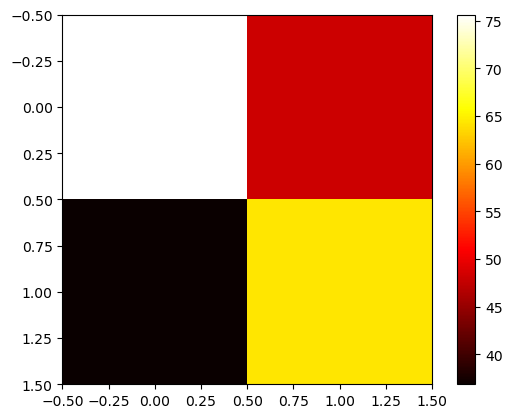

In [173]:
import matplotlib.pyplot as plt

data = Temperatura.reshape(2,2)
fig, ax = plt.subplots()
im = ax.imshow(data, cmap=plt.get_cmap('hot'))
fig.colorbar(im)
plt.show()
